# Val-Ablation: n_val Sweep

Training on 1, 2, 4, 8, 16, 32 in-distribution validation samples with batch_size=1.
Total sample-passes match the main experiments (tydiqa: 9392, samsum: 20800).
5 seeds per configuration to measure variance from random sample selection.

In [172]:
import json
import os
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from glob import glob

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [173]:
# ============================================
# Configuration
# ============================================
SCRATCH_DIR = '/work/hdd/bfwm/phu1/Project'
out_dir = f'{SCRATCH_DIR}/Dr.Post-Training/SFT'
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

model = 'Llama-3.2-1B'

TASKS = [
    {'task': 'tydiqa', 'title': 'TYDIQA'},
    {'task': 'samsum', 'title': 'SAMSUM'},
]

METHODS = ['Standard-Full', 'Standard-LoRA', 'Standard-MeSO']
METHOD_DISPLAY = {'Standard-Full': 'Full', 'Standard-LoRA': 'LoRA', 'Standard-MeSO': 'MeSO'}

N_VALS = [1, 2, 4, 8, 16, 32]

# Distinct colors for each n_val — high contrast, colorblind-friendly
NVAL_COLORS = {
    1:  '#d62728',   # red
    2:  '#ff7f0e',   # orange
    4:  '#2ca02c',   # green
    8:  '#1f77b4',   # blue
    16: '#9467bd',   # purple
    32: '#17becf',   # cyan
}
NVAL_LINESTYLES = {
    1: '-', 2: '-', 4: '-', 8: '--', 16: '--', 32: '--',
}

In [174]:
# ============================================
# Discover and load all val-ablation experiments
# Aggregate across seeds: mean +/- std
# ============================================

def load_eval_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return {
        'steps': np.array([e['step'] for e in data]),
        'val_perplexity': np.array([e['val_perplexity'] for e in data]),
        'eval_perplexity': np.array([e['eval_perplexity'] for e in data]),
        'train_wall_time': np.array([
            e.get('train_wall_time', e.get('wall_time', 0)) for e in data
        ]),
    }

# Collect per-seed data first: raw[task][method][n_val] = [(seed, data), ...]
raw = {}

for tc in TASKS:
    task = tc['task']
    raw[task] = {}
    print(f"\n{'='*60}")
    print(f"  {tc['title']}")
    print(f"{'='*60}")

    pattern = f"{task}_val_{task}-{model}-*-s*"
    dirs = sorted(glob(f"{out_dir}/{pattern}"))

    for d in dirs:
        name = Path(d).name
        m_method = re.search(r'1B-(Standard-\w+)-ms', name)
        m_nval = re.search(r'-v(\d+)-s', name)
        m_seed = re.search(r'-s(\d+)$', name)
        if not m_method or not m_nval or not m_seed:
            continue
        method = m_method.group(1)
        n_val = int(m_nval.group(1))
        seed = int(m_seed.group(1))

        eval_path = f"{d}/evaluation_results.json"
        if not os.path.exists(eval_path):
            continue

        data = load_eval_results(eval_path)
        if method not in raw[task]:
            raw[task][method] = {}
        if n_val not in raw[task][method]:
            raw[task][method][n_val] = []
        raw[task][method][n_val].append((seed, data))

# Aggregate across seeds
# all_data[task][method][n_val] = {steps, *_mean, *_std, n_seeds, seeds}
all_data = {}

for task in raw:
    all_data[task] = {}
    for method in raw[task]:
        all_data[task][method] = {}
        for n_val in sorted(raw[task][method]):
            entries = raw[task][method][n_val]
            seeds = sorted([s for s, _ in entries])
            runs = [d for _, d in sorted(entries, key=lambda x: x[0])]

            min_len = min(len(r['steps']) for r in runs)
            steps = runs[0]['steps'][:min_len]

            agg = {'steps': steps, 'n_seeds': len(seeds), 'seeds': seeds}
            for key in ['val_perplexity', 'eval_perplexity', 'train_wall_time']:
                stacked = np.stack([r[key][:min_len] for r in runs])
                agg[f'{key}_mean'] = np.nanmean(stacked, axis=0)
                agg[f'{key}_std'] = np.nanstd(stacked, axis=0)

            all_data[task][method][n_val] = agg
            print(f"  {method:<20} n_val={n_val:>2}  {agg['n_seeds']} seeds  {min_len} pts  seeds={seeds}")

total = sum(len(nv) for t in all_data.values() for m in t.values() for nv in [m])
print(f"\nLoaded: {total} (task, method, n_val) combinations")


  TYDIQA

  SAMSUM
  Standard-Full        n_val= 1  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-Full        n_val= 2  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-Full        n_val= 4  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-Full        n_val= 8  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-Full        n_val=16  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-Full        n_val=32  5 seeds  36 pts  seeds=[2, 22, 42, 62, 82]
  Standard-LoRA        n_val= 1  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-LoRA        n_val= 2  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-LoRA        n_val= 4  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-LoRA        n_val= 8  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-LoRA        n_val=16  5 seeds  48 pts  seeds=[2, 22, 42, 62, 82]
  Standard-LoRA        n_val=32  5 seeds  36 pts  seeds=[2, 22, 42, 62, 82]
  Standard-MeSO        n_val= 1  5 seeds  48 pts  seeds=[2, 22, 42, 

## Perplexity vs Steps

For each task: 2 rows (val perplexity, eval perplexity) x 3 columns (Full, LoRA, MeSO).
Each subplot shows one line per n_val.

Saved: ./figures/ablation_tydiqa_steps.pdf


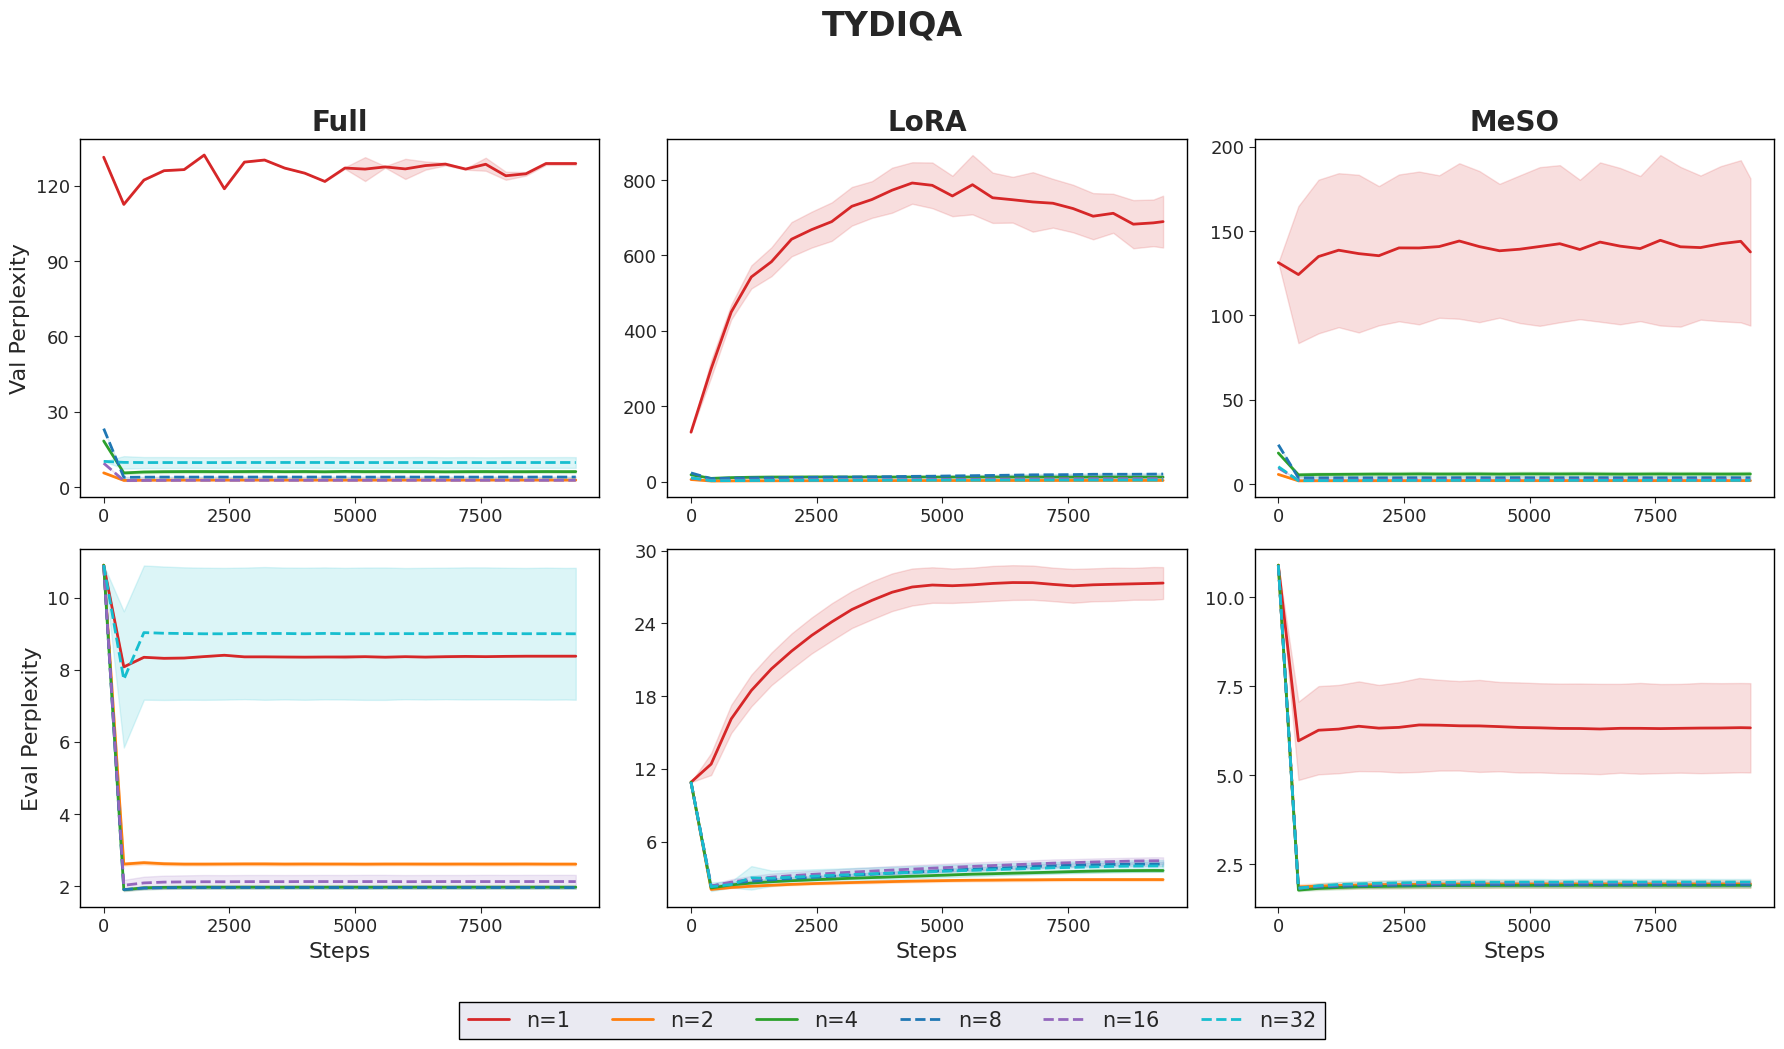

Saved: ./figures/ablation_samsum_steps.pdf


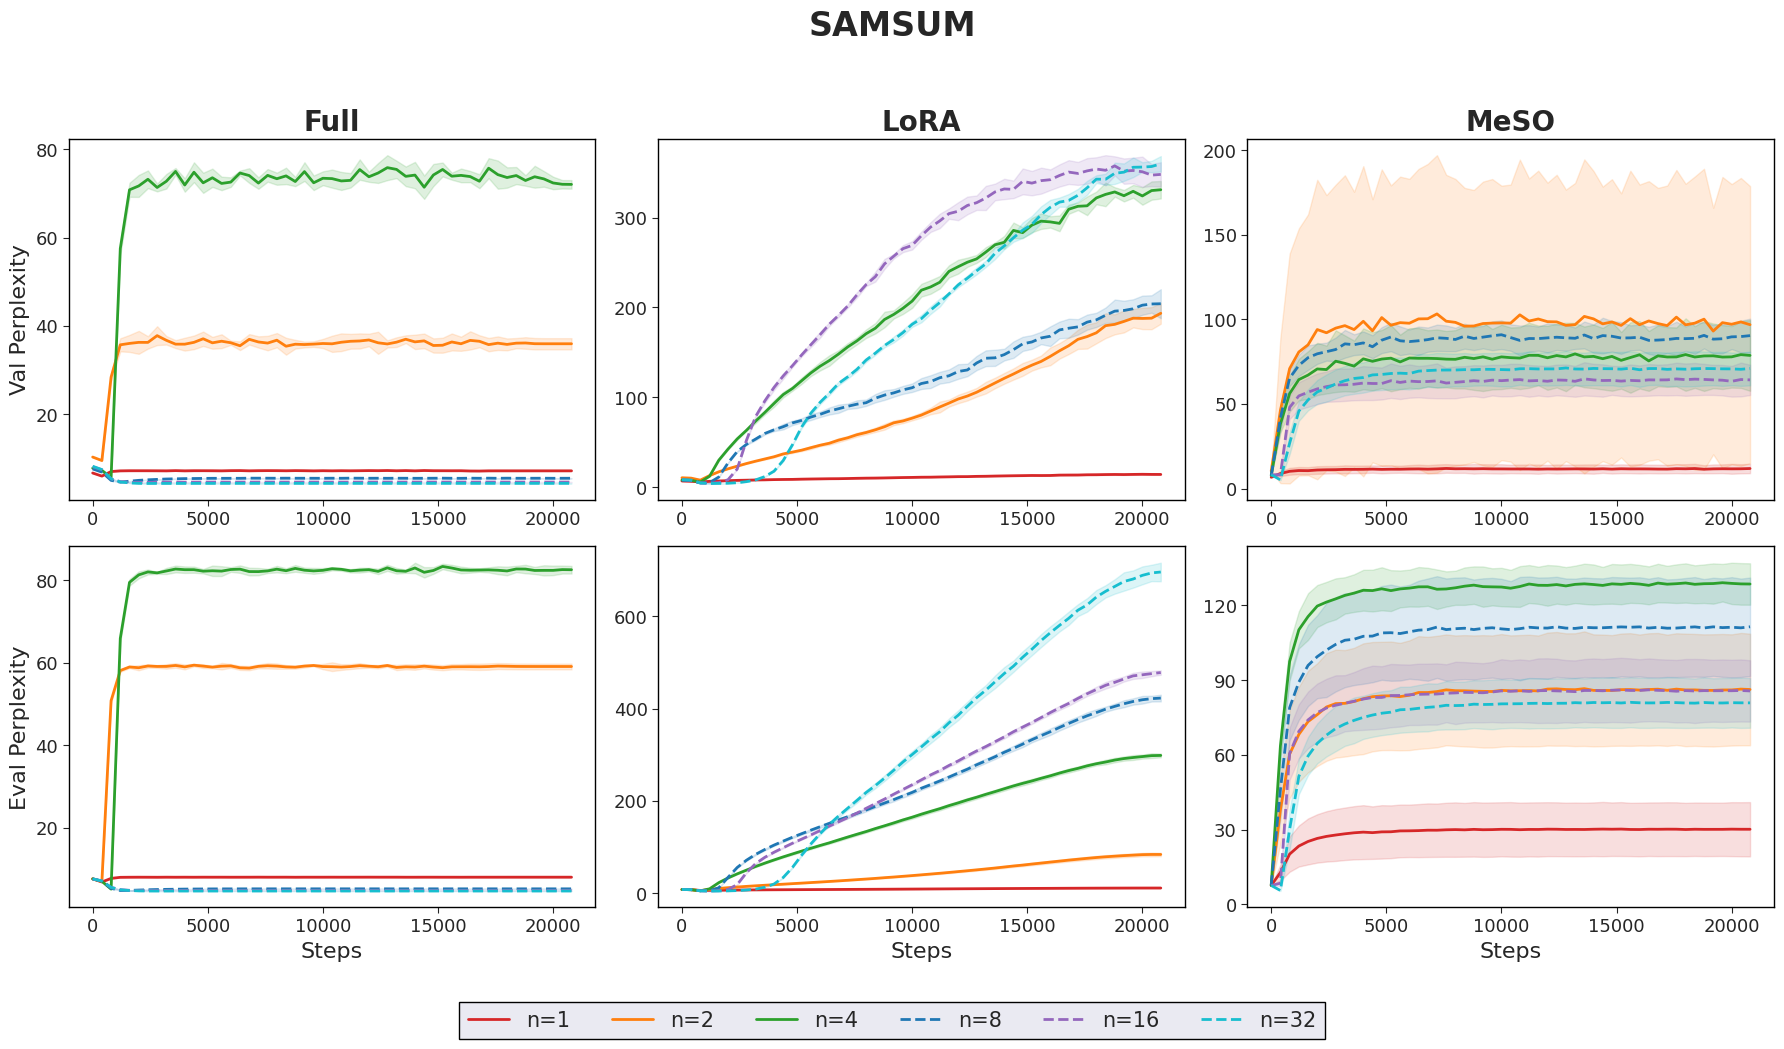

In [175]:
for tc in TASKS:
    task = tc['task']
    task_data = all_data.get(task, {})
    if not task_data:
        print(f"No data for {task}")
        continue

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    fig.patch.set_facecolor('white')
    fig.suptitle(tc['title'], fontsize=24, fontweight='bold', y=1.01)

    row_labels = ['Val Perplexity', 'Eval Perplexity']
    row_keys = ['val_perplexity', 'eval_perplexity']

    for col_idx, method in enumerate(METHODS):
        method_data = task_data.get(method, {})
        display = METHOD_DISPLAY.get(method, method)

        for row_idx, (label, key) in enumerate(zip(row_labels, row_keys)):
            ax = axes[row_idx, col_idx]
            ax.set_facecolor('white')

            for n_val in N_VALS:
                if n_val not in method_data:
                    continue
                d = method_data[n_val]
                steps = d['steps']
                mean = d[f'{key}_mean']
                std = d[f'{key}_std']
                n_seeds = d['n_seeds']

                mask = ~np.isnan(mean)
                if mask.sum() == 0:
                    continue
                color = NVAL_COLORS[n_val]
                ls = NVAL_LINESTYLES.get(n_val, '-')
                ax.plot(steps[mask], mean[mask], linewidth=2,
                        label=f'n={n_val}', color=color, linestyle=ls)
                if n_seeds > 1:
                    ax.fill_between(steps[mask],
                                    (mean - std)[mask], (mean + std)[mask],
                                    color=color, alpha=0.15)

            # Formatting
            if row_idx == 0:
                ax.set_title(display, fontsize=20, fontweight='bold')
            if row_idx == 1:
                ax.set_xlabel('Steps', fontsize=16)
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=16)
            ax.grid(True, alpha=0.3, linewidth=0.5)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.0)
                spine.set_color('black')
            ax.tick_params(axis='both', which='major', labelsize=13,
                           direction='out', length=4)
            ax.xaxis.set_major_locator(MaxNLocator(5))
            ax.yaxis.set_major_locator(MaxNLocator(5))

    # Shared legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center',
                   ncol=len(N_VALS), fontsize=15, frameon=True,
                   edgecolor='black', fancybox=False, framealpha=1.0,
                   bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout(rect=[0, 0.04, 1, 0.98])
    filepath = os.path.join(save_dir, f'ablation_{task}_steps.pdf')
    fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f'Saved: {filepath}')
    plt.show()

## Perplexity vs Wall Time

Same layout but x-axis is train_wall_time (minutes).

Saved: ./figures/ablation_tydiqa_walltime.pdf


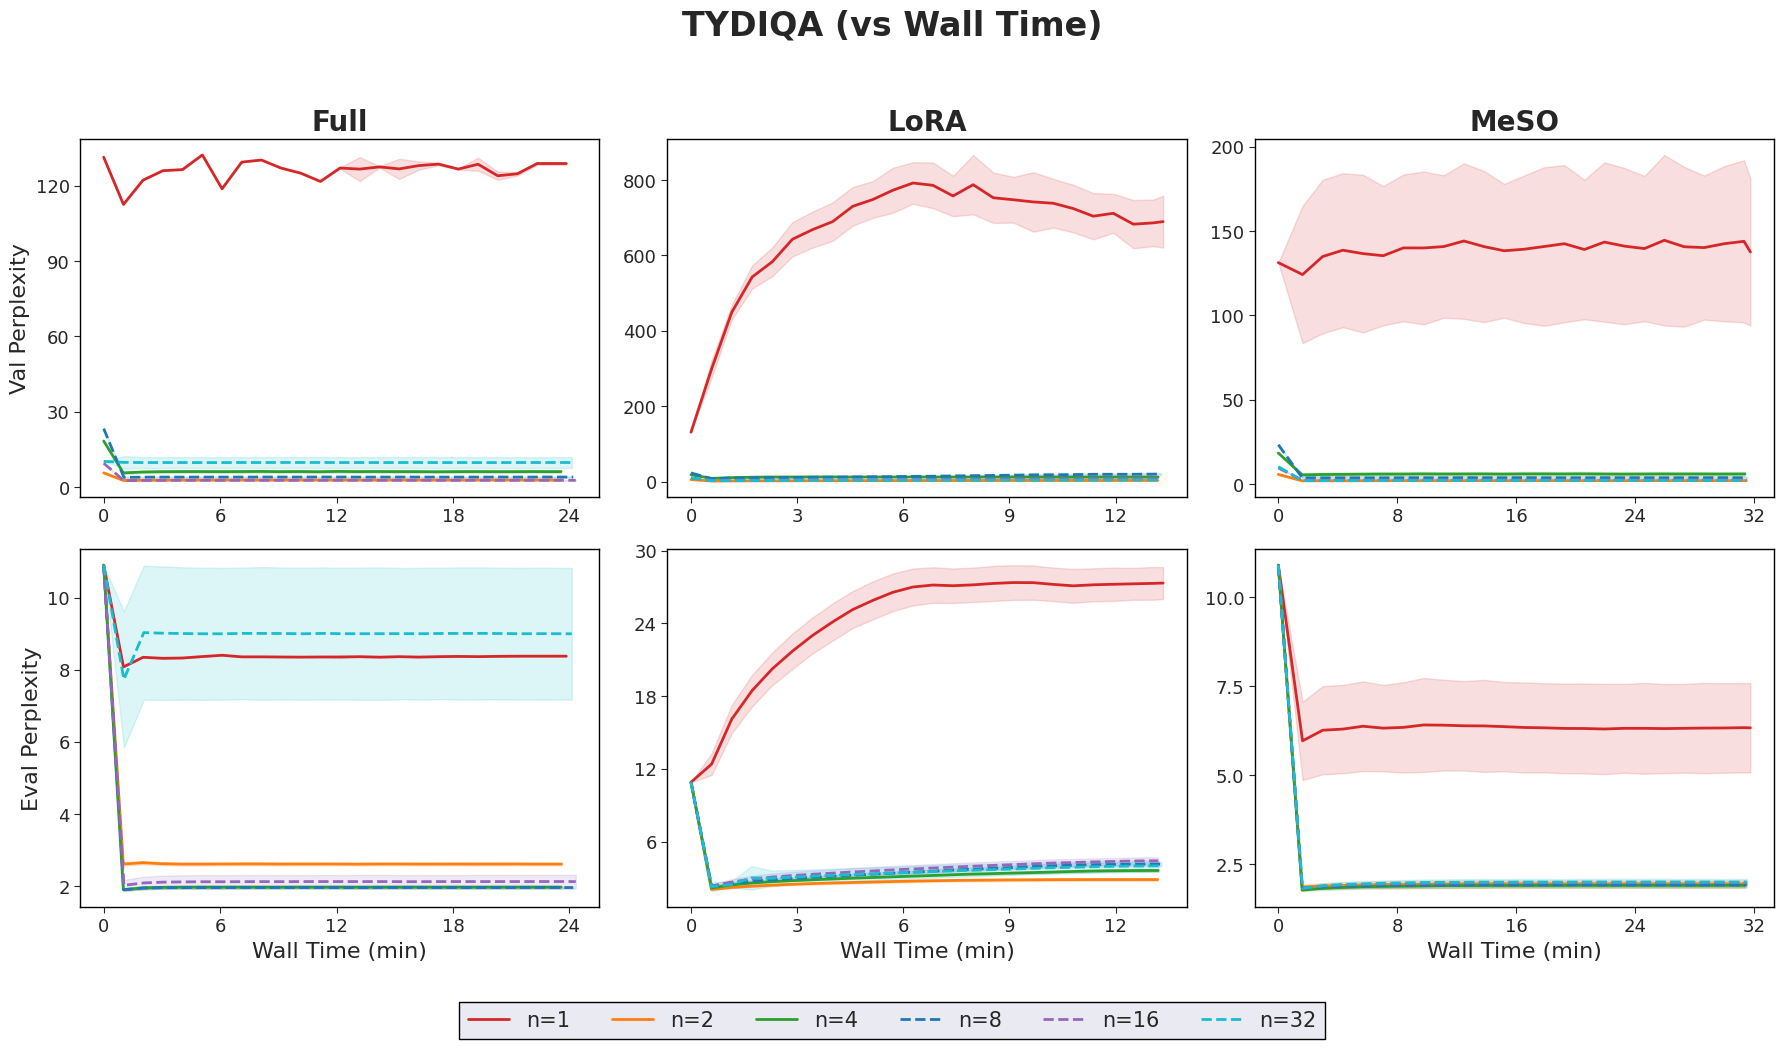

Saved: ./figures/ablation_samsum_walltime.pdf


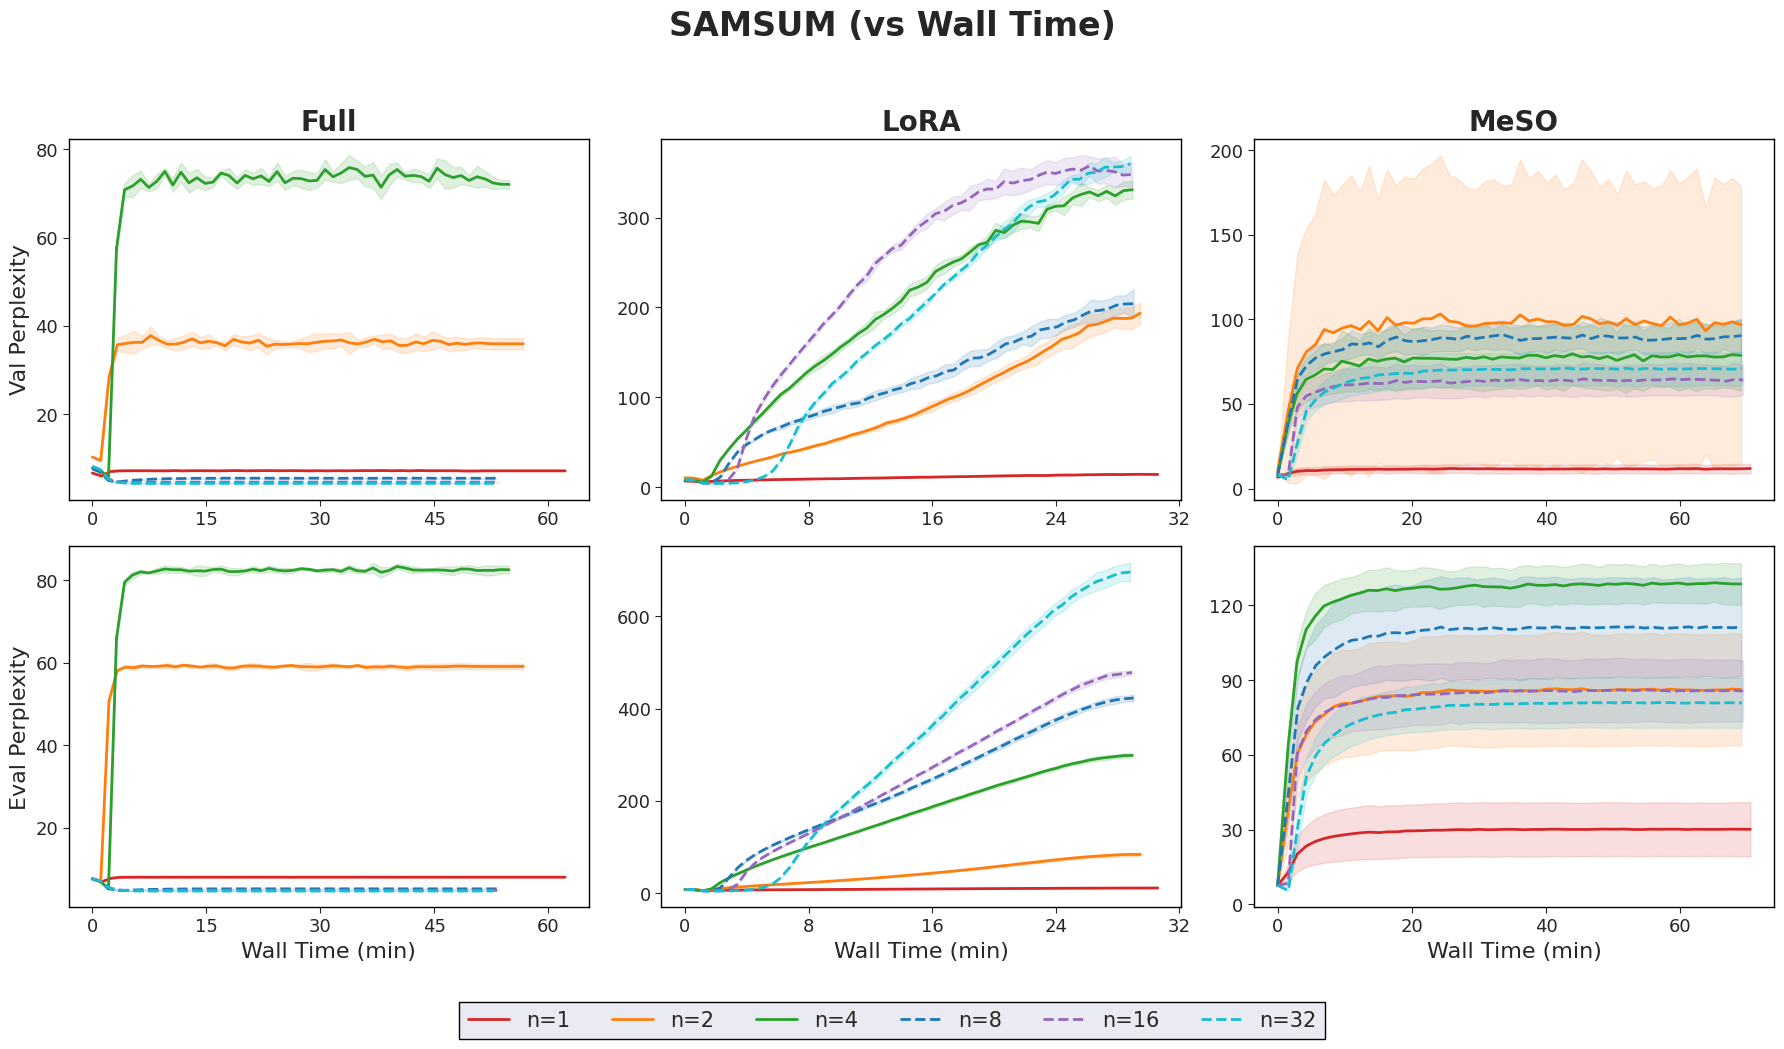

In [176]:
for tc in TASKS:
    task = tc['task']
    task_data = all_data.get(task, {})
    if not task_data:
        continue

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    fig.patch.set_facecolor('white')
    fig.suptitle(f"{tc['title']} (vs Wall Time)", fontsize=24, fontweight='bold', y=1.01)

    row_labels = ['Val Perplexity', 'Eval Perplexity']
    row_keys = ['val_perplexity', 'eval_perplexity']

    for col_idx, method in enumerate(METHODS):
        method_data = task_data.get(method, {})
        display = METHOD_DISPLAY.get(method, method)

        for row_idx, (label, key) in enumerate(zip(row_labels, row_keys)):
            ax = axes[row_idx, col_idx]
            ax.set_facecolor('white')

            for n_val in N_VALS:
                if n_val not in method_data:
                    continue
                d = method_data[n_val]
                x = d['train_wall_time_mean'] / 60.0
                mean = d[f'{key}_mean']
                std = d[f'{key}_std']
                n_seeds = d['n_seeds']

                mask = ~np.isnan(mean) & ~np.isnan(x)
                if mask.sum() == 0:
                    continue
                color = NVAL_COLORS[n_val]
                ls = NVAL_LINESTYLES.get(n_val, '-')
                ax.plot(x[mask], mean[mask], linewidth=2,
                        label=f'n={n_val}', color=color, linestyle=ls)
                if n_seeds > 1:
                    ax.fill_between(x[mask],
                                    (mean - std)[mask], (mean + std)[mask],
                                    color=color, alpha=0.15)

            if row_idx == 0:
                ax.set_title(display, fontsize=20, fontweight='bold')
            if row_idx == 1:
                ax.set_xlabel('Wall Time (min)', fontsize=16)
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=16)
            ax.grid(True, alpha=0.3, linewidth=0.5)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.0)
                spine.set_color('black')
            ax.tick_params(axis='both', which='major', labelsize=13,
                           direction='out', length=4)
            ax.xaxis.set_major_locator(MaxNLocator(5))
            ax.yaxis.set_major_locator(MaxNLocator(5))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center',
                   ncol=len(N_VALS), fontsize=15, frameon=True,
                   edgecolor='black', fancybox=False, framealpha=1.0,
                   bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout(rect=[0, 0.04, 1, 0.98])
    filepath = os.path.join(save_dir, f'ablation_{task}_walltime.pdf')
    fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
    print(f'Saved: {filepath}')
    plt.show()

## Downstream Task Performance

Task-specific metrics (F1/EM for TyDiQA, ROUGE for SAMSUM) from eval.sh, aggregated across seeds.

In [177]:
# ============================================
# Load downstream task metrics from eval.sh results
# ============================================

TASK_METRICS = {
    'tydiqa': {
        'result_file': 'tydiqa_results.json',
        'metrics': ['f1_score', 'exact_match'],
        'display_names': ['F1', 'EM'],
        'primary': 'f1_score',
    },
    'samsum': {
        'result_file': 'samsum_results.json',
        'metrics': ['rouge1', 'rouge2', 'rougeL'],
        'display_names': ['R-1', 'R-2', 'R-L'],
        'primary': 'rougeL',
    },
}

# task_metrics[task][method][n_val] = {metric_mean, metric_std, n_seeds, seeds}
task_metrics = {}

for tc in TASKS:
    task = tc['task']
    tm = TASK_METRICS.get(task)
    if not tm:
        continue
    task_metrics[task] = {}

    pattern = f"{task}_val_{task}-{model}-*-s*"
    dirs = sorted(glob(f"{out_dir}/{pattern}"))

    # Collect per-seed results
    raw_tm = {}
    for d in dirs:
        name = Path(d).name
        m_method = re.search(r'1B-(Standard-\w+)-ms', name)
        m_nval = re.search(r'-v(\d+)-s', name)
        m_seed = re.search(r'-s(\d+)$', name)
        if not m_method or not m_nval or not m_seed:
            continue
        method = m_method.group(1)
        n_val = int(m_nval.group(1))
        seed = int(m_seed.group(1))

        result_path = f"{d}/{tm['result_file']}"
        if not os.path.exists(result_path):
            continue
        with open(result_path) as f:
            result = json.load(f)

        key = (method, n_val)
        if key not in raw_tm:
            raw_tm[key] = []
        raw_tm[key].append((seed, result))

    # Aggregate
    for (method, n_val), entries in raw_tm.items():
        if method not in task_metrics[task]:
            task_metrics[task][method] = {}
        seeds = sorted([s for s, _ in entries])
        agg = {'n_seeds': len(seeds), 'seeds': seeds}
        for metric in tm['metrics']:
            vals = [r.get(metric, float('nan')) for _, r in entries]
            agg[f'{metric}_mean'] = np.nanmean(vals)
            agg[f'{metric}_std'] = np.nanstd(vals)
        task_metrics[task][method][n_val] = agg

# Print tables
def _fmt_task(mean, std, n_seeds):
    if np.isnan(mean):
        return '--'
    if n_seeds > 1 and not np.isnan(std):
        return f"{mean:.1f} +/- {std:.1f}"
    return f"{mean:.1f}"

for tc in TASKS:
    task = tc['task']
    tm = TASK_METRICS[task]
    data = task_metrics.get(task, {})
    if not data:
        print(f"\nNo task results for {tc['title']} yet. Eval job may still be running.")
        continue

    for metric, display in zip(tm['metrics'], tm['display_names']):
        print(f"\n{'='*110}")
        print(f"  {tc['title']} -- {display} by n_val (mean +/- std across seeds)")
        print(f"{'='*110}")

        header = f"{'Method':<15} {'Seeds':<6}"
        for n in N_VALS:
            header += f" {'n=' + str(n):>16}"
        print(header)
        print('-' * 110)

        for method in METHODS:
            md = data.get(method, {})
            display_name = METHOD_DISPLAY.get(method, method)
            n_seeds = next((d['n_seeds'] for d in md.values()), 0)
            row = f"{display_name:<15} {n_seeds:<6}"
            for n in N_VALS:
                if n in md:
                    d = md[n]
                    row += f" {_fmt_task(d[f'{metric}_mean'], d[f'{metric}_std'], d['n_seeds']):>16}"
                else:
                    row += f" {'--':>16}"
            print(row)

        print(f"{'='*110}")


  TYDIQA -- F1 by n_val (mean +/- std across seeds)
Method          Seeds               n=1              n=2              n=4              n=8             n=16             n=32
--------------------------------------------------------------------------------------------------------------
Full            5          26.1 +/- 0.7     46.0 +/- 0.5     52.4 +/- 0.7     52.8 +/- 1.3     59.0 +/- 1.8     10.4 +/- 6.7
LoRA            5          22.1 +/- 0.3     47.0 +/- 0.8     47.2 +/- 1.3     50.5 +/- 0.2     49.5 +/- 2.3    47.9 +/- 13.9
MeSO            5          21.9 +/- 1.0     42.8 +/- 2.4     47.7 +/- 3.4     55.4 +/- 1.8     57.5 +/- 1.0     62.4 +/- 1.1

  TYDIQA -- EM by n_val (mean +/- std across seeds)
Method          Seeds               n=1              n=2              n=4              n=8             n=16             n=32
--------------------------------------------------------------------------------------------------------------
Full            5           0.4 +/- 0.1     21.